# GIZ CBCR Project: ETR analysis

- Author: Mario Cuenda García
- Created: February 2025

**Description**

This notebook analyses the ETRs of all countries, which is necessary to do the adjustment of the double counting.

## 0. Load packages and define basic functions

In [1]:
import pandas as pd
import numpy as np
from config import *
from tjn_tools import data_processing
import statsmodels.formula.api as smf
from itertools import product
from scipy.stats.mstats import winsorize

[TJN TOOLS: Data processing] Module loaded.
[TJN TOOLS: Other functions] Module loaded.
[TJN TOOLS: Paths] Module loaded. Sharepoint FOUND at /Users/mariocuendagarcia/Library/CloudStorage/OneDrive-SharedLibraries-TaxJusticeNetworkLtd


## 1. Before corrections - ETR paid by domestic MNEs in their own country and the ETR paid by foreign MNEs

### 1.1. Call the dataset we need for the ETRs, and filter for positive profits

In [2]:
cbcr_dataset = pd.read_excel(f'{data_intermediate}/2_cbcr_second_cleaned_version_wide_format.xlsx')

# Filter if grouping = Sub-groups with positive profits	
cbcr_dataset = cbcr_dataset[cbcr_dataset['grouping'] == 'Sub-groups with positive profits']

# Keep the following columns: iso_parent, parent_jurisdiction, iso_partner, partner_jurisdiction, grouping, year, profit_loss_before_income_tax, adjusted_profit_loss_before_income_tax, income_tax_accrued_current_year 
cbcr_dataset = cbcr_dataset[['iso_parent', 'parent_jurisdiction', 'iso_partner', 'partner_jurisdiction', 'grouping', 'year', 'profit_loss_before_income_tax', 'adjusted_profit_loss_before_income_tax', 'income_tax_accrued_current_year']]

# Sample of reporting jurisdictions and partner jurisdictions 
parent_countries = cbcr_dataset['iso_parent'].drop_duplicates()
print(parent_countries)

# Display number in the format 1,000,000,000
pd.options.display.float_format = '{:,.3f}'.format


1        ARE
403      ARG
687      AUS
1699     AUT
1802     AZE
1874     BEL
2375     BGR
2429     BHR
2510     BMU
3940     BRA
4528     CAN
4795     CHE
6992     CHL
7274     CHN
9140     CYM
10646    DEU
13064    DNK
14877    ESP
16227    FIN
16297    FRA
17330    GBR
17418    GRC
18011    HKG
19429    IDN
20359    IMN
20428    IND
21987    IRL
22017    ITA
23629    JPN
25710    KOR
25780    LTU
25861    LUX
27654    MAR
27665    MEX
29008    MUS
29051    MYS
29420    NLD
29611    NOR
30225    NZL
30407    PER
30883    PRT
31280    ROU
32510    SAU
33254    SGP
33872    SVN
33938    SWE
34042    TUN
34066    TUR
34502    USA
36529    ZAF
Name: iso_parent, dtype: object


### 1.2 Filter for Domestic MNEs and estimate their ETR in their parent country

In [3]:
domestic_MNES_without_correction = cbcr_dataset

# Filter for all iso_partner = iso_parent
domestic_MNES_without_correction = domestic_MNES_without_correction[domestic_MNES_without_correction['iso_parent'] == domestic_MNES_without_correction['iso_partner']]

# Calculate the domestic ETR
domestic_MNES_without_correction["domestic_MNEs_etr"] = domestic_MNES_without_correction["income_tax_accrued_current_year"] / domestic_MNES_without_correction["profit_loss_before_income_tax"]

# Keep iso_partner, year, profit_loss_before_income_tax, income_tax_accrued_current_year, and domestic_MNEs_etr
domestic_MNES_without_correction = domestic_MNES_without_correction[['iso_partner', 'year', 'profit_loss_before_income_tax', 'income_tax_accrued_current_year', 'domestic_MNEs_etr']]

# Rename profit_loss_before_income_tax to domestic_profit_loss_before_income_tax, and income_tax_accrued_current_year to domestic_income_tax_accrued_current_year
domestic_MNES_without_correction = domestic_MNES_without_correction.rename(columns={'profit_loss_before_income_tax':'domestic_profit_loss_before_income_tax', 'income_tax_accrued_current_year':'domestic_income_tax_accrued_current_year'})

domestic_MNES_without_correction

/var/folders/kj/y_rfkb696353czt_6gnx_jkc0000gn/T/ipykernel_21892/3557355881.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  domestic_MNES_without_correction["domestic_MNEs_etr"] = domestic_MNES_without_correction["income_tax_accrued_current_year"] / domestic_MNES_without_correction["profit_loss_before_income_tax"]


,iso_partner,year,domestic_profit_loss_before_income_tax,domestic_income_tax_accrued_current_year,domestic_MNEs_etr
7,ARE,2021,"41,101,926,875.000","58,284,597.000",0.001
403,ARG,2017,"4,433,285,457.000","1,581,473,284.000",0.357
404,ARG,2018,"17,394,703,622.000","1,234,150,798.000",0.071
405,ARG,2019,"2,619,205,748.000","46,653,712.770",0.018
406,ARG,2020,"4,002,785,911.000","679,071,515.500",0.170
...,...,...,...,...,...
37440,ZAF,2017,"28,963,577,125.000","2,859,314,070.000",0.099
37441,ZAF,2018,"35,283,842,532.000","3,410,166,841.000",0.097
37442,ZAF,2019,"16,985,754,101.000","1,865,362,067.000",0.110
37443,ZAF,2020,"14,782,553,753.000","2,076,466,653.000",0.140


### 1.3 Filter for Foreign MNEs in each country and estimate the ETR they pay in each country

In [4]:
foreign_MNEs_without_corrections = cbcr_dataset

# Drop if iso_partner = iso_parent
foreign_MNEs_without_corrections = foreign_MNEs_without_corrections[foreign_MNEs_without_corrections['iso_parent'] != foreign_MNEs_without_corrections['iso_partner']]

# For each iso_partner and year, sum the columns profit_loss_before_income_tax, and income_tax_accrued_current_year
foreign_MNEs_without_corrections = foreign_MNEs_without_corrections.groupby(['iso_partner', 'year']).agg({'profit_loss_before_income_tax':'sum', 'income_tax_accrued_current_year':'sum'}).reset_index()

# Estimate the ETR of Foreign MNEs
foreign_MNEs_without_corrections["foreign_MNEs_etr"] = foreign_MNEs_without_corrections["income_tax_accrued_current_year"] / foreign_MNEs_without_corrections["profit_loss_before_income_tax"]

# Rename profit_loss_before_income_tax to foreign_profit_loss_before_income_tax, and income_tax_accrued_current_year to foreign_income_tax_accrued_current_year
foreign_MNEs_without_corrections = foreign_MNEs_without_corrections.rename(columns={'profit_loss_before_income_tax':'foreign_profit_loss_before_income_tax', 'income_tax_accrued_current_year':'foreign_income_tax_accrued_current_year'})

foreign_MNEs_without_corrections

,iso_partner,year,foreign_profit_loss_before_income_tax,foreign_income_tax_accrued_current_year,foreign_MNEs_etr
0,A,2016,"26,498,262,045.000","4,320,423,924.800",0.163
1,A,2017,"66,863,895,899.000","12,186,545,240.000",0.182
2,A,2018,"74,408,302,200.700","11,088,247,232.133",0.149
3,A,2019,"79,175,736,447.530","12,355,315,564.684",0.156
4,A,2020,"84,103,453,468.500","13,039,547,569.003",0.155
...,...,...,...,...,...
1187,ZWE,2017,"218,042,167.000","84,211,027.000",0.386
1188,ZWE,2018,"561,419,611.506","96,166,130.363",0.171
1189,ZWE,2019,"593,693,027.610","29,362,505.488",0.049
1190,ZWE,2020,"256,708,588.720","37,051,825.468",0.144


### 1.4 Merge the two datasets and save the dataset

In [5]:
# Merge the two datasets by iso_partner and year
etr_MNEs_without_corrections = domestic_MNES_without_correction.merge(foreign_MNEs_without_corrections, on=['iso_partner', 'year'], how='left')

# Generate the variable difference_domestic_foreign_etr = foreign_etr - domestic_etr
etr_MNEs_without_corrections["difference_domestic_foreign_etr"] = etr_MNEs_without_corrections["foreign_MNEs_etr"] - etr_MNEs_without_corrections["domestic_MNEs_etr"]

# Save the dataset
etr_MNEs_without_corrections.to_excel(f'{output_tables}/ETR Analysis/ETRs_domestic_foreign_without corrections.xlsx', index=False)

etr_MNEs_without_corrections

,iso_partner,year,domestic_profit_loss_before_income_tax,domestic_income_tax_accrued_current_year,domestic_MNEs_etr,foreign_profit_loss_before_income_tax,foreign_income_tax_accrued_current_year,foreign_MNEs_etr,difference_domestic_foreign_etr
0,ARE,2021,"41,101,926,875.000","58,284,597.000",0.001,"23,095,934,338.000","7,637,899,070.000",0.331,0.329
1,ARG,2017,"4,433,285,457.000","1,581,473,284.000",0.357,"13,091,737,204.000","3,259,249,048.800",0.249,-0.108
2,ARG,2018,"17,394,703,622.000","1,234,150,798.000",0.071,"11,946,063,303.877","3,455,891,210.046",0.289,0.218
3,ARG,2019,"2,619,205,748.000","46,653,712.770",0.018,"10,272,328,606.534","2,768,079,611.971",0.269,0.252
4,ARG,2020,"4,002,785,911.000","679,071,515.500",0.170,"6,946,895,652.100","2,159,216,387.630",0.311,0.141
...,...,...,...,...,...,...,...,...,...
231,ZAF,2017,"28,963,577,125.000","2,859,314,070.000",0.099,"5,802,626,142.000","1,125,147,270.700",0.194,0.095
232,ZAF,2018,"35,283,842,532.000","3,410,166,841.000",0.097,"8,514,031,517.539","1,500,993,814.050",0.176,0.080
233,ZAF,2019,"16,985,754,101.000","1,865,362,067.000",0.110,"5,682,359,266.711","1,177,753,304.453",0.207,0.097
234,ZAF,2020,"14,782,553,753.000","2,076,466,653.000",0.140,"3,948,184,387.755","944,276,638.901",0.239,0.099


### 1.5 Summary Statistics of the Differences between the ETRs paid by domestic and foreign MNEs

This shows, for each country, how many time the foreign ETR is above the local ETR.

In [6]:
# Group by iso_parent and calculate the required values

differences = etr_MNEs_without_corrections.groupby('iso_partner').agg(
    total_observations=('difference_domestic_foreign_etr', 'size'),
    positive_difference=('difference_domestic_foreign_etr', lambda x: (x > 0).sum())
).reset_index()

differences

,iso_partner,total_observations,positive_difference
0,ARE,1,1
1,ARG,5,4
2,AUS,6,2
3,AUT,5,5
4,AZE,1,1
5,BEL,6,6
6,BGR,2,0
7,BHR,1,0
8,BMU,6,4
9,BRA,6,6


### 1.6 Generate the Correction Table

In [7]:
# Generate "table_corrections" by filtering "etr_MNEs" and keeping iso_parent, year, and difference_foreign_local
table_corrections = etr_MNEs_without_corrections[['iso_partner', 'year', 'difference_domestic_foreign_etr']]

# Move the dataset to wide by year
table_corrections = table_corrections.pivot(index='iso_partner', columns='year', values='difference_domestic_foreign_etr').reset_index()

# Save the dataset
table_corrections.to_excel(f'{output_tables}/ETR Analysis/correction_table.xlsx', index=False)

table_corrections

year,iso_partner,2016,2017,2018,2019,2020,2021
0,ARE,NaN,NaN,NaN,NaN,NaN,0.329
1,ARG,NaN,-0.108,0.218,0.252,0.141,0.015
2,AUS,0.019,-0.134,-0.062,-0.044,0.095,-0.090
3,AUT,0.104,NaN,0.024,0.021,0.010,0.020
4,AZE,NaN,NaN,NaN,NaN,NaN,0.100
5,BEL,0.108,0.099,0.101,0.112,0.013,0.083
6,BGR,NaN,NaN,NaN,NaN,-0.109,-0.007
7,BHR,NaN,NaN,NaN,NaN,NaN,-0.121
8,BMU,0.012,0.003,-0.008,0.020,-0.001,0.013
9,BRA,0.053,0.204,0.136,0.147,0.091,0.087


### 1.7 Correction Table for 2017 to share with Javier García-Bernardo

In [8]:
# Generate "table_correction_2017" by filtering for the year 2017
table_correction_2017 = etr_MNEs_without_corrections[etr_MNEs_without_corrections['year'] == 2017]

# Save in excel
table_correction_2017.to_excel(f'{output_tables}/ETR Analysis/correction_table_2017.xlsx', index=False)


## 2. After corrections - ETR paid by domestic MNEs in their own country and the ETR paid by foreign MNEs

### 2.1. Call the dataset we need for the ETRs, and filter for positive profits

In [9]:
# Open the dataset
main_cbcr_dataset = pd.read_csv(f'{data_final}/main_cbcr_dataset.csv')

# Filter if grouping = Sub-groups with positive profits	
main_cbcr_dataset = main_cbcr_dataset[main_cbcr_dataset['grouping'] == 'Sub-groups with positive profits']

# Keep the following columns: iso_parent, parent_jurisdiction, iso_partner, partner_jurisdiction, grouping, year, profit_loss_before_income_tax, adjusted_profit_loss_before_income_tax, income_tax_accrued_current_year 
main_cbcr_dataset = main_cbcr_dataset[['iso_parent', 'parent_jurisdiction', 'iso_partner', 'partner_jurisdiction', 'grouping', 'year', 'profit_loss_before_income_tax', 'profit_loss_before_income_tax_corrected', 'adjusted_profit_loss_before_income_tax', 'income_tax_accrued_current_year']]

# Sample of reporting jurisdictions and partner jurisdictions 
parent_countries = cbcr_dataset['iso_parent'].drop_duplicates()
print(parent_countries)

# Display number in the format 1,000,000,000
pd.options.display.float_format = '{:,.3f}'.format


1        ARE
403      ARG
687      AUS
1699     AUT
1802     AZE
1874     BEL
2375     BGR
2429     BHR
2510     BMU
3940     BRA
4528     CAN
4795     CHE
6992     CHL
7274     CHN
9140     CYM
10646    DEU
13064    DNK
14877    ESP
16227    FIN
16297    FRA
17330    GBR
17418    GRC
18011    HKG
19429    IDN
20359    IMN
20428    IND
21987    IRL
22017    ITA
23629    JPN
25710    KOR
25780    LTU
25861    LUX
27654    MAR
27665    MEX
29008    MUS
29051    MYS
29420    NLD
29611    NOR
30225    NZL
30407    PER
30883    PRT
31280    ROU
32510    SAU
33254    SGP
33872    SVN
33938    SWE
34042    TUN
34066    TUR
34502    USA
36529    ZAF
Name: iso_parent, dtype: object


### 2.2. Filter for Domestic MNEs and estimate their ETR in their parent country

In [10]:
# Filter for domestic_MNEs
domestic_MNEs_with_corrections = main_cbcr_dataset

# Filter for all iso_partner = iso_parent
domestic_MNEs_with_corrections = domestic_MNEs_with_corrections[domestic_MNEs_with_corrections['iso_parent'] == domestic_MNEs_with_corrections['iso_partner']]
 
# Calculate the domestic ETR
domestic_MNEs_with_corrections["domestic_MNEs_etr"] = domestic_MNEs_with_corrections["income_tax_accrued_current_year"] / domestic_MNEs_with_corrections["profit_loss_before_income_tax_corrected"]

# Keep iso_partner, year, profit_loss_before_income_tax, income_tax_accrued_current_year, and domestic_MNEs_etr
domestic_MNEs_with_corrections = domestic_MNEs_with_corrections[['iso_partner', 'year', 'profit_loss_before_income_tax_corrected', 'income_tax_accrued_current_year', 'domestic_MNEs_etr']]

# Rename profit_loss_before_income_tax to domestic_profit_loss_before_income_tax, and income_tax_accrued_current_year to domestic_income_tax_accrued_current_year
domestic_MNEs_with_corrections = domestic_MNEs_with_corrections.rename(columns={'profit_loss_before_income_tax_corrected':'domestic_profit_loss_before_income_tax_corrected', 'income_tax_accrued_current_year':'domestic_income_tax_accrued_current_year'})

domestic_MNEs_with_corrections

/var/folders/kj/y_rfkb696353czt_6gnx_jkc0000gn/T/ipykernel_21892/892955837.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  domestic_MNEs_with_corrections["domestic_MNEs_etr"] = domestic_MNEs_with_corrections["income_tax_accrued_current_year"] / domestic_MNEs_with_corrections["profit_loss_before_income_tax_corrected"]


,iso_partner,year,domestic_profit_loss_before_income_tax_corrected,domestic_income_tax_accrued_current_year,domestic_MNEs_etr
7,ARE,2021,"41,101,926,875.000","58,284,597.000",0.001
403,ARG,2017,"4,433,285,457.000","1,581,473,284.000",0.357
404,ARG,2018,"11,306,557,354.300","1,234,150,798.000",0.109
405,ARG,2019,"1,702,483,736.200","46,653,712.770",0.027
406,ARG,2020,"4,002,785,911.000","679,071,515.500",0.170
...,...,...,...,...,...
37440,ZAF,2017,"18,826,325,131.250","2,859,314,070.000",0.152
37441,ZAF,2018,"22,934,497,645.800","3,410,166,841.000",0.149
37442,ZAF,2019,"11,040,740,165.650","1,865,362,067.000",0.169
37443,ZAF,2020,"14,782,553,753.000","2,076,466,653.000",0.140


### 2.3 Filter for Foreign MNEs in each country and estimate the ETR they pay in each country

In [11]:
foreign_MNEs_with_corrections = main_cbcr_dataset

# Drop if iso_partner = iso_parent
foreign_MNEs_with_corrections = foreign_MNEs_with_corrections[foreign_MNEs_with_corrections['iso_parent'] != foreign_MNEs_with_corrections['iso_partner']]

# For each iso_partner and year, sum the columns profit_loss_before_income_tax, and income_tax_accrued_current_year
foreign_MNEs_with_corrections = foreign_MNEs_with_corrections.groupby(['iso_partner', 'year']).agg({'profit_loss_before_income_tax_corrected':'sum', 'income_tax_accrued_current_year':'sum'}).reset_index()

# Estimate the ETR of Foreign MNEs
foreign_MNEs_with_corrections["foreign_MNEs_etr"] = foreign_MNEs_with_corrections["income_tax_accrued_current_year"] / foreign_MNEs_with_corrections["profit_loss_before_income_tax_corrected"]

# Rename profit_loss_before_income_tax to foreign_profit_loss_before_income_tax, and income_tax_accrued_current_year to foreign_income_tax_accrued_current_year and income_tax_accrued_current_year to domestic_income_tax_accrued_current_year to domestic_income_tax_accrued_current_year
foreign_MNEs_with_corrections = foreign_MNEs_with_corrections.rename(columns={'profit_loss_before_income_tax_corrected':'foreign_profit_loss_before_income_tax_corrected', 'income_tax_accrued_current_year':'foreign_income_tax_accrued_current_year'})

foreign_MNEs_with_corrections

,iso_partner,year,foreign_profit_loss_before_income_tax_corrected,foreign_income_tax_accrued_current_year,foreign_MNEs_etr
0,A,2016,"25,173,348,942.750","4,320,423,924.800",0.172
1,A,2017,"63,520,701,104.050","12,186,545,240.000",0.192
2,A,2018,"70,687,887,090.665","11,088,247,232.133",0.157
3,A,2019,"78,442,038,275.404","12,355,315,564.684",0.158
4,A,2020,"84,103,453,468.500","13,039,547,569.003",0.155
...,...,...,...,...,...
1187,ZWE,2017,"218,042,167.000","84,211,027.000",0.386
1188,ZWE,2018,"561,419,611.506","96,166,130.363",0.171
1189,ZWE,2019,"593,693,027.610","29,362,505.488",0.049
1190,ZWE,2020,"256,708,588.720","37,051,825.468",0.144


### 2.4 Merge the two datasets and save the dataset

In [12]:
# Merge the two datasets by iso_partner and year
etr_MNEs_with_corrections = domestic_MNEs_with_corrections.merge(foreign_MNEs_with_corrections, on=['iso_partner', 'year'], how='left')

# Generate the variable difference_domestic_foreign_etr = foreign_etr - domestic_etr
etr_MNEs_with_corrections["difference_domestic_foreign_etr"] = etr_MNEs_with_corrections["foreign_MNEs_etr"] - etr_MNEs_with_corrections["domestic_MNEs_etr"]

# Save the dataset
etr_MNEs_with_corrections.to_excel(f'{output_tables}/ETR Analysis/ETRs_domestic_foreign_with_corrections.xlsx', index=False)

etr_MNEs_with_corrections

,iso_partner,year,domestic_profit_loss_before_income_tax_corrected,domestic_income_tax_accrued_current_year,domestic_MNEs_etr,foreign_profit_loss_before_income_tax_corrected,foreign_income_tax_accrued_current_year,foreign_MNEs_etr,difference_domestic_foreign_etr
0,ARE,2021,"41,101,926,875.000","58,284,597.000",0.001,"23,095,934,338.000","7,637,899,070.000",0.331,0.329
1,ARG,2017,"4,433,285,457.000","1,581,473,284.000",0.357,"13,091,737,204.000","3,259,249,048.800",0.249,-0.108
2,ARG,2018,"11,306,557,354.300","1,234,150,798.000",0.109,"11,946,063,303.877","3,455,891,210.046",0.289,0.180
3,ARG,2019,"1,702,483,736.200","46,653,712.770",0.027,"10,272,328,606.534","2,768,079,611.971",0.269,0.242
4,ARG,2020,"4,002,785,911.000","679,071,515.500",0.170,"6,946,895,652.100","2,159,216,387.630",0.311,0.141
...,...,...,...,...,...,...,...,...,...
231,ZAF,2017,"18,826,325,131.250","2,859,314,070.000",0.152,"5,802,626,142.000","1,125,147,270.700",0.194,0.042
232,ZAF,2018,"22,934,497,645.800","3,410,166,841.000",0.149,"8,514,031,517.539","1,500,993,814.050",0.176,0.028
233,ZAF,2019,"11,040,740,165.650","1,865,362,067.000",0.169,"5,682,359,266.711","1,177,753,304.453",0.207,0.038
234,ZAF,2020,"14,782,553,753.000","2,076,466,653.000",0.140,"3,948,184,387.755","944,276,638.901",0.239,0.099


## 3. Generate Figure "Domestic and foreign ETRs before and after correction for double counting"

### 3.1 Panel A. Original Data - no correction

In [13]:
# Filter and keep the following columns: iso_partner, year, domestic_MNEs_etr, and foreign_MNEs_etr
etr_MNEs_without_corrections = etr_MNEs_without_corrections[['iso_partner', 'year', 'domestic_MNEs_etr', 'foreign_MNEs_etr']]

# Drop values if > 0
etr_MNEs_without_corrections = etr_MNEs_without_corrections[etr_MNEs_without_corrections['domestic_MNEs_etr'] > 0]
etr_MNEs_without_corrections = etr_MNEs_without_corrections[etr_MNEs_without_corrections['foreign_MNEs_etr'] > 0]

# Drop values if year is 2020 and 2021
etr_MNEs_without_corrections = etr_MNEs_without_corrections[etr_MNEs_without_corrections['year'] != 2020]
etr_MNEs_without_corrections = etr_MNEs_without_corrections[etr_MNEs_without_corrections['year'] != 2021]

etr_MNEs_without_corrections #[etr_MNEs_without_corrections['iso_partner'] == 'BEL']

,iso_partner,year,domestic_MNEs_etr,foreign_MNEs_etr
1,ARG,2017,0.357,0.249
2,ARG,2018,0.071,0.289
3,ARG,2019,0.018,0.269
6,AUS,2016,0.199,0.217
7,AUS,2017,0.227,0.093
...,...,...,...,...
227,USA,2019,0.123,0.116
230,ZAF,2016,0.101,0.214
231,ZAF,2017,0.099,0.194
232,ZAF,2018,0.097,0.176


The number of observations above the 45 degree line is: 42
The number of observations below the 45 degree line is: 98


/var/folders/kj/y_rfkb696353czt_6gnx_jkc0000gn/T/ipykernel_21892/1900653908.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


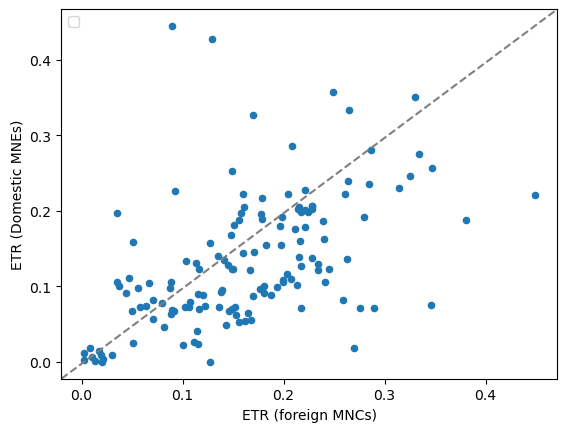

In [ ]:
# Generate a graph with domestic_MNEs_etr values on the vertical axis and foreign_MNEs_etr values on the horizontal axis
import matplotlib.pyplot as plt

ax = etr_MNEs_without_corrections.plot.scatter(x='foreign_MNEs_etr', y='domestic_MNEs_etr')
ax.set_xlabel("ETR (foreign MNCs)")
ax.set_ylabel("ETR (Domestic MNEs)")
ax.plot([0, 1], [0, 1], transform=ax.transAxes, linestyle='--', color='gray')
plt.legend()

# Save the plot
plt.savefig(f'{output_tables}/ETR Analysis/Figure_1_Appendix_Panel_A.png')

# Can you count how many observations are above the 45 degree line?
etr_MNEs_without_corrections['above_45'] = etr_MNEs_without_corrections['foreign_MNEs_etr'] < etr_MNEs_without_corrections['domestic_MNEs_etr']
print(f"The number of observations above the 45 degree line is: {etr_MNEs_without_corrections['above_45'].sum()}")

# Can you count how many observations are below the 45 degree line?
etr_MNEs_without_corrections['below_45'] = etr_MNEs_without_corrections['foreign_MNEs_etr'] > etr_MNEs_without_corrections['domestic_MNEs_etr']
print(f"The number of observations below the 45 degree line is: {etr_MNEs_without_corrections['below_45'].sum()}")

### 3.2 Panel B. Corrected for double counting

Replicate what is done in Section 2 above - Actually call it number 3 and the figures, let's make it number 4.

In [15]:
# Filter and keep the following columns: iso_partner, year, domestic_MNEs_etr, and foreign_MNEs_etr
etr_MNEs_with_corrections = etr_MNEs_with_corrections[['iso_partner', 'year', 'domestic_MNEs_etr', 'foreign_MNEs_etr']]

# Drop values if > 0
etr_MNEs_with_corrections = etr_MNEs_with_corrections[etr_MNEs_with_corrections['domestic_MNEs_etr'] > 0]
etr_MNEs_with_corrections = etr_MNEs_with_corrections[etr_MNEs_with_corrections['foreign_MNEs_etr'] > 0]

# Drop values if year is 2020 and 2021
etr_MNEs_with_corrections = etr_MNEs_with_corrections[etr_MNEs_with_corrections['year'] != 2020]
etr_MNEs_with_corrections = etr_MNEs_with_corrections[etr_MNEs_with_corrections['year'] != 2021]

etr_MNEs_with_corrections

,iso_partner,year,domestic_MNEs_etr,foreign_MNEs_etr
1,ARG,2017,0.357,0.249
2,ARG,2018,0.109,0.289
3,ARG,2019,0.027,0.269
6,AUS,2016,0.306,0.217
7,AUS,2017,0.227,0.093
...,...,...,...,...
227,USA,2019,0.123,0.116
230,ZAF,2016,0.156,0.214
231,ZAF,2017,0.152,0.194
232,ZAF,2018,0.149,0.176


The number of observations above the 45 degree line is: 85
The number of observations below the 45 degree line is: 55


/var/folders/kj/y_rfkb696353czt_6gnx_jkc0000gn/T/ipykernel_21892/1269110527.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


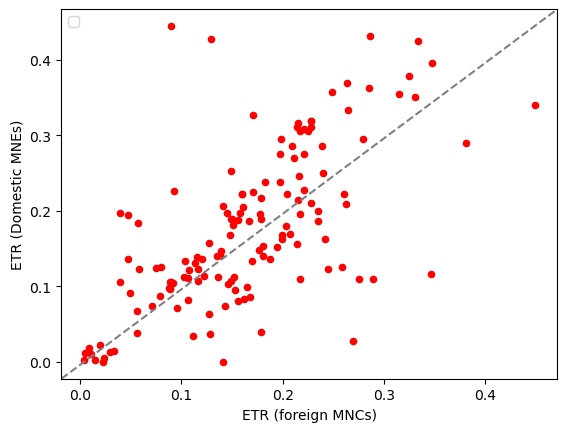

In [35]:
# Generate a graph with domestic_MNEs_etr values on the vertical axis and foreign_MNEs_etr values on the horizontal axis
import matplotlib.pyplot as plt

ax = etr_MNEs_with_corrections.plot.scatter(x='foreign_MNEs_etr', y='domestic_MNEs_etr', color='red')
ax.set_xlabel("ETR (foreign MNCs)")
ax.set_ylabel("ETR (Domestic MNEs)")
ax.plot([0, 1], [0, 1], transform=ax.transAxes, linestyle='--', color='gray')
plt.legend()

# Save the plot
plt.savefig(f'{output_tables}/ETR Analysis/Figure_1_Appendix_Panel_B.png')

# Can you count how many observations are above the 45 degree line?
etr_MNEs_with_corrections['above_45'] = etr_MNEs_with_corrections['foreign_MNEs_etr'] < etr_MNEs_with_corrections['domestic_MNEs_etr']
print(f"The number of observations above the 45 degree line is: {etr_MNEs_with_corrections['above_45'].sum()}")

# Can you count how many observations are below the 45 degree line?
etr_MNEs_with_corrections['below_45'] = etr_MNEs_with_corrections['foreign_MNEs_etr'] > etr_MNEs_with_corrections['domestic_MNEs_etr']
print(f"The number of observations below the 45 degree line is: {etr_MNEs_with_corrections['below_45'].sum()}")

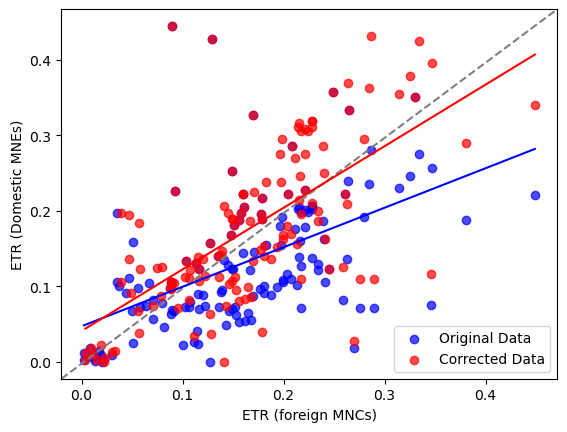

In [ ]:
import numpy as np

# Generate a combined scatterplot for both datasets
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Scatterplot for etr_MNEs_without_corrections
ax.scatter(etr_MNEs_without_corrections['foreign_MNEs_etr'], 
           etr_MNEs_without_corrections['domestic_MNEs_etr'], 
           color='blue', label='Original Data', alpha=0.7)

# Scatterplot for etr_MNEs_with_corrections
ax.scatter(etr_MNEs_with_corrections['foreign_MNEs_etr'], 
           etr_MNEs_with_corrections['domestic_MNEs_etr'], 
           color='red', label='Corrected Data', alpha=0.7)

# Add a 45º reference line
ax.plot([0, 1], [0, 1], transform=ax.transAxes, linestyle='--', color='gray')

# Regression line for etr_MNEs_without_corrections
coeffs_without = np.polyfit(etr_MNEs_without_corrections['foreign_MNEs_etr'], 
                            etr_MNEs_without_corrections['domestic_MNEs_etr'], 1)
x_vals = np.linspace(etr_MNEs_without_corrections['foreign_MNEs_etr'].min(), 
                     etr_MNEs_without_corrections['foreign_MNEs_etr'].max(), 100)
ax.plot(x_vals, coeffs_without[0] * x_vals + coeffs_without[1], color='blue', linestyle='-')

# Regression line for etr_MNEs_with_corrections
coeffs_with = np.polyfit(etr_MNEs_with_corrections['foreign_MNEs_etr'], 
                         etr_MNEs_with_corrections['domestic_MNEs_etr'], 1)
x_vals = np.linspace(etr_MNEs_with_corrections['foreign_MNEs_etr'].min(), 
                     etr_MNEs_with_corrections['foreign_MNEs_etr'].max(), 100)
ax.plot(x_vals, coeffs_with[0] * x_vals + coeffs_with[1], color='red', linestyle='-')

# Add labels, legend, and title
ax.set_xlabel("ETR (foreign MNCs)")
ax.set_ylabel("ETR (Domestic MNEs)")
ax.legend()
#ax.set_title('Scatterplot of Domestic vs Foreign ETRs with Regression Lines')

# Save the plot
plt.savefig(f'{output_tables}/ETR Analysis/Figure_1_Appendix_Panel_C.png')

plt.show()

## Appendix 1: Different dictionaries to correct for double counting of dividends.

Depending on which methodology we use for the double counting of dividends, the dictionaries we use for each correction will vary. To keep track of them, we will store them here, under several names.

### Correction 1: A reduction of 35% for all countries and 10% for foreign profits in tax havens


In [18]:
# Define correction values for each year in dictionaries

# Domestic corrections
correction_domestic = {
    2016: {"AUS": 0.35, "AUT": 0.35, "BEL": 0.35, "BMU": 0.35, "BRA": 0.35,
        "CAN": 0.35, "CHL": 0, "CHN": 0, "DNK": 0.35, "FIN": 0.35,
        "FRA": 0.35, "IDN": 0.35, "IRL": 0.35, "ITA": 0.35, "JPN": 0.35, "KOR": 0,
        "LUX": 0.35, "MEX": 0.35, "NLD": 0, "NOR": 0.35,
        "SVN": 0, "SWE": 0.35, "USA": 0, "ZAF": 0.35},
    
    2017: {"ARG": 0, "AUS": 0, "AUT": 0.35, "BEL": 0.35, "BMU": 0.35,
        "BRA": 0.35, "CAN": 0.35, "CHE": 0, "CHL": 0.35, "CHN": 0.35, 
        "DEU": 0.35, "DNK": 0.35, "ESP": 0.35, "FIN": 0.35, "FRA": 0.35, "GBR": 0,
        "GRC": 0, "IDN": 0.35, "IMN": 0.35, "IND": 0.35,
        "IRL": 0.35, "ITA": 0.35, "JPN": 0.35, "KOR": 0.35, "LUX": 0.35,
        "MEX": 0, "MYS": 0.35, "NLD": 0, "NOR": 0.35, "PER": 0,
        "ROU": 0.35, "SGP": 0.35, "SVN": 0, "SWE": 0, "USA": 0,
        "ZAF": 0.35},

    2018: {"ARG": 0.35, "AUS": 0, "AUT": 0.35, "BEL": 0.35, "BMU": 0,
        "BRA": 0.35, "CAN": 0.35, "CHE": 0, "CHL": 0, "CHN": 0.35,
        "CYM": 0, "DEU": 0.35, "DNK": 0.35, "ESP": 0.35, "FIN": 0.35,
        "FRA": 0.35, "GBR": 0.35, "GRC": 0, "HKG": 0.35, "IDN": 0.35,
        "IMN": 0.35, "IND": 0.35, "IRL": 0.35, "ITA": 0.35, "JPN": 0.35, "KOR": 0,
        "LTU": 0.35, "LUX": 0.35, "MEX": 0, "MYS": 0.35, "NLD": 0,
        "NOR": 0.35, "NZL": 0.35, "PER": 0, "ROU": 0.35, "SAU": 0,
        "SGP": 0, "SVN": 0, "SWE": 0.35, "USA": 0,
        "ZAF": 0.35},
    
    2019: {"ARG": 0.35, "AUS": 0, "AUT": 0.35, "BEL": 0.35, "BMU": 0.35,
        "BRA": 0.35, "CAN": 0.35, "CHE": 0, "CHL": 0, "CHN": 0.35,
        "CYM": 0, "DEU": 0.35, "DNK": 0.35, "ESP": 0.35, "FIN": 0.35,
        "FRA": 0.35, "GBR": 0, "GRC": 0, "HKG": 0.35, "IDN": 0.35,
        "IMN": 0.35, "IND": 0.35, "IRL": 0.35, "ITA": 0.35, "JPN": 0.35,
        "LTU": 0.35, "LUX": 0.35, "MEX": 0.35, "MUS": 0, "MYS": 0.35, "NLD": 0,
        "NOR": 0.35, "NZL": 0.35, "PER": 0.35, "PRT": 0.35,
        "ROU": 0.35, "SAU": 0, "SGP": 0, "SVN": 0.35, "SWE": 0.35,
        "TUR": 0, "USA": 0, "ZAF": 0.35},
    
    2020: {},
    2021: {}
}

# Foreign corrections
#correction_foreign = {
#    2016: {"USA": 0.1},
#    2017: {"USA": 0.1},
#    2018: {"USA": 0.1},
#    2019: {"USA": 0.1},
#    2020: {},
#    2021: {}
#}

# Tax havens and country groups corrections
correction_taxhavens = {year: {key: 0.1 for key in tax_havens} for year in range(2016, 2020)}

# Here include corrections for both other_country_groups and aggregated_country_groups
correction_countrygroups = {year: {key: 0.05 for key in other_country_groups | aggregated_country_groups} for year in range(2016, 2020)}


### Correction 2: A close replication of Garcia-Bernardo and Jansky (2024)

In [19]:
# Define correction values for each year in dictionaries

# Domestic corrections
correction_domestic = {
    2016: {"AUS": 0.35, "AUT": 0.35, "BEL": 0.50, "BMU": 0.35, "BRA": 0.35,
        "CAN": 0.35, "CHL": 0.35, "CHN": 0, "DNK": 0.35, "FIN": 0.35,
        "FRA": 0.35, "IDN": 0.35, "IRL": 0, "ITA": 0, "JPN": 0.35,
        "LUX": 0.35, "MEX": 0, "NLD": 0.16, "NOR": 0.35,
        "SVN": 0, "SWE": 0.585, "USA": 0.40, "ZAF": 0.35},
    
    2017: {"ARG": 0.35, "AUS": 0.35, "AUT": 0.35, "BEL": 0.50, "BMU": 0.50,
        "BRA": 0.35, "CAN": 0.35, "CHE": 0.35, "CHL": 0.35, "CHN": 0, 
        "DEU": 0.35, "DNK": 0.35, "ESP": 0.35, "FIN": 0.35, "FRA": 0.35,
        "GRC": 0.35, "IDN": 0.35, "IMN": 0.50, "IND": 0.35,
        "IRL": 0, "ITA": 0, "JPN": 0.35, "KOR": 0, "LUX": 0.35,
        "MEX": 0, "MYS": 0.35, "NOR": 0.35, "PER": 0.35,
        "ROU": 0.35, "SGP": 0.50, "SVN": 0, "SWE": 0.52, "USA": 0.40,
        "ZAF": 0.35},

    2018: {"ARG": 0.35, "AUS": 0.35, "AUT": 0.35, "BEL": 0.50, "BMU": 0.35,
        "BRA": 0.35, "CAN": 0.35, "CHE": 0.35, "CHL": 0.35, "CHN": 0,
        "CYM": 0, "DEU": 0.35, "DNK": 0.35, "ESP": 0.35, "FIN": 0.35,
        "FRA": 0.35, "GRC": 0.35, "HKG": 0.35, "IDN": 0.35,
        "IMN": 0.50, "IND": 0.35, "IRL": 0, "ITA": 0.19, "JPN": 0.35,
        "LTU": 0.35, "LUX": 0.35, "MEX": 0, "MYS": 0.35,
        "NOR": 0.35, "NZL": 0.35, "PER": 0.35, "ROU": 0.35, "SAU": 0.35,
        "SGP": 0.50, "SVN": 0, "SWE": 0.61, "TUR": 0.35, "USA": 0.40,
        "ZAF": 0.35},
    
    2019: {"ARG": 0.35, "AUS": 0.35, "AUT": 0.35, "BEL": 0.50, "BMU": 0.35,
        "BRA": 0.35, "CAN": 0.35, "CHE": 0.35, "CHL": 0.35, "CHN": 0,
        "CYM": 0, "DEU": 0.35, "DNK": 0.35, "ESP": 0.35, "FIN": 0.35,
        "FRA": 0.35, "GRC": 0.35, "HKG": 0.35, "IDN": 0.35,
        "IMN": 0.50, "IND": 0.35, "IRL": 0, "ITA": 0.19, "JPN": 0.35,
        "LTU": 0.35, "LUX": 0.35, "MEX": 0, "MUS": 0.35, "MYS": 0.35,
        "NOR": 0.35, "NZL": 0.35, "PER": 0.35, "PRT": 0.35,
        "ROU": 0.35, "SAU": 0.35, "SGP": 0.50, "SVN": 0, "SWE": 0.57,
        "TUR": 0.35, "USA": 0.40, "ZAF": 0.35},
    
    2020: {},
    2021: {}
}

# Foreign corrections
correction_foreign = {
    2016: {"USA": 0.1},
    2017: {"USA": 0.1},
    2018: {"USA": 0.39},
    2019: {"USA": 0.39},
    2020: {},
    2021: {}
}

# Tax havens and country groups corrections
correction_taxhavens = {year: {key: 0.1 for key in tax_havens} for year in range(2016, 2020)}

# Here include corrections for both other_country_groups and aggregated_country_groups
correction_countrygroups = {year: {key: 0.05 for key in other_country_groups | aggregated_country_groups} for year in range(2016, 2020)}


## Appendix 2: Estimate ETRs of MNEs in their parent countries vs foreign countries

Some note: at some point, I did it incorrectly. I was doing the ETR of the MNEs of one country in their own country vs what they paid abroad. For instance, I was looking at the ETR of Belgian MNEs at home, vs the ETR of what Belgian MNEs declared in all the countries where they had activity. This was wrong. The correct one is what is done in section 2. But since the estimates are done, I will keep them below just in case they might be useful at some point. I called them "global ETRS", as this would allow to see what MNEs face at home and abroad.

In [20]:
global_etrs = cbcr_dataset

# Calculate ETRs for all the partner countries
global_etrs["etr"] = global_etrs["income_tax_accrued_current_year"] / global_etrs["profit_loss_before_income_tax"]

#####################################################################################

# Obtain the local ETR
local_etr = global_etrs[global_etrs['iso_parent'] == global_etrs['iso_partner']]
# Keep just iso_parent and etr
local_etr = local_etr[['iso_parent', 'year', 'etr']]
# Rename the column to etr_local
local_etr = local_etr.rename(columns={'etr':'etr_local'})

#####################################################################################

# Obtain the foreign ETR by summing all foreign jurisdictions by income_tax_accrued_current_year and by profit_loss_before_income_tax and then do the ETR
foreign_etr = global_etrs[global_etrs['iso_parent'] != global_etrs['iso_partner']]
foreign_etr = foreign_etr.groupby(['iso_parent', 'year']).agg({'income_tax_accrued_current_year':'sum', 'profit_loss_before_income_tax':'sum'}).reset_index()
# Estimate ETR 
foreign_etr["etr"] = foreign_etr["income_tax_accrued_current_year"] / foreign_etr["profit_loss_before_income_tax"]
# Keep just iso_parent and etr
foreign_etr = foreign_etr[['iso_parent', 'year', 'etr']]
# Rename the column to etr_foreign_v2
foreign_etr = foreign_etr.rename(columns={'etr':'etr_foreign'})

#####################################################################################

# Merge the 3 datasets by iso_parent
etrs_merged = local_etr.merge(foreign_etr, on=['iso_parent', 'year'], how='left')

#####################################################################################

# Generate new variable difference foreign local = etr_foreign_v2 - er_local
etrs_merged["difference_foreign_local"] = etrs_merged["etr_foreign"] - etrs_merged["etr_local"]

# Save the dataset
#etrs_merged.to_excel(f'{data_intermediate}/ETRs_domestic_foreign_global.xlsx', index=False)

etrs_merged

,iso_parent,year,etr_local,etr_foreign,difference_foreign_local
0,ARE,2021,0.001,0.123,0.122
1,ARG,2017,0.357,0.038,-0.319
2,ARG,2018,0.071,0.244,0.173
3,ARG,2019,0.018,0.044,0.026
4,ARG,2020,0.170,0.069,-0.101
...,...,...,...,...,...
231,ZAF,2017,0.099,0.019,-0.080
232,ZAF,2018,0.097,0.027,-0.069
233,ZAF,2019,0.110,0.139,0.029
234,ZAF,2020,0.140,0.152,0.012


### A.1. Summary Statistics of the differences

This shows, for each country, how many time the foreign ETR (what they pay abroad) is above the local ETR (what they pay at home).

In [21]:
# Group by iso_parent and calculate the required values

differences = etrs_merged.groupby('iso_parent').agg(
    total_observations=('difference_foreign_local', 'size'),
    positive_difference=('difference_foreign_local', lambda x: (x > 0).sum())
).reset_index()

differences

,iso_parent,total_observations,positive_difference
0,ARE,1,1
1,ARG,5,2
2,AUS,6,1
3,AUT,5,4
4,AZE,1,0
5,BEL,6,2
6,BGR,2,0
7,BHR,1,0
8,BMU,6,6
9,BRA,6,3


### A.2. Generates the (incorrect) correction table

In [22]:
# Generate "table_corrections" by filtering "etrs_merged" and keeping iso_parent, year, and difference_foreign_local
table_corrections = etrs_merged[['iso_parent', 'year', 'difference_foreign_local']]

# Move the dataset to wide by year
table_corrections = table_corrections.pivot(index='iso_parent', columns='year', values='difference_foreign_local').reset_index()

# Save the dataset
#table_corrections.to_excel(f'{data_intermediate}/correction_table.xlsx', index=False)

table_corrections

year,iso_parent,2016,2017,2018,2019,2020,2021
0,ARE,NaN,NaN,NaN,NaN,NaN,0.122
1,ARG,NaN,-0.319,0.173,0.026,-0.101,-0.160
2,AUS,-0.082,-0.081,-0.097,-0.029,0.014,-0.081
3,AUT,0.099,NaN,0.116,0.058,-0.003,0.090
4,AZE,NaN,NaN,NaN,NaN,NaN,-0.078
5,BEL,0.035,-0.054,-0.038,-0.037,-0.016,0.057
6,BGR,NaN,NaN,NaN,NaN,-0.101,-0.048
7,BHR,NaN,NaN,NaN,NaN,NaN,-0.018
8,BMU,0.105,0.136,0.147,0.143,0.111,0.156
9,BRA,-0.109,0.046,-0.057,0.018,-0.055,0.033


## Appendix 3: Testing the functions of Notebook 1.1. - Section 3

Notebook 1.1. - Section 3 is, for now, "Calculate the ETRs". Section 3.1 defines the functions needed to calculate the ETRs, whereas Section 3.2 runs the functions and gives the ETRs. However, that section is aggregated and can lead to confusion. So this section below "disaggregates" the functions of Section 3.1 so that everyone can see what is done for each year.



In [23]:

# Show me in non-scientific notation
pd.options.display.float_format = '{:,.3f}'.format

# Load and filter dataset
cbcr_dataset = pd.read_excel(f'{data_intermediate}/4_cbcr_data_logged_variables.xlsx')

df = cbcr_dataset[["iso_parent", "iso_partner", "year", "partner_jurisdiction", "grouping", 
                   "income_tax_accrued_current_year", "profit_loss_before_income_tax", 
                   "profit_loss_before_income_tax_corrected"]]

df = df[df["grouping"] == "Sub-groups with positive profits"]

# -------------------------
# ----- YEAR: 2016 --------
# -------------------------
df_2016 = df[(df["year"] >= 2014) & (df["year"] <= 2018)]
df_2016 = df_2016.dropna(subset=["income_tax_accrued_current_year"])

df_domestic_2016 = df_2016[df_2016["iso_parent"] == df_2016["iso_partner"]]
df_foreign_2016 = df_2016[df_2016["iso_parent"] != df_2016["iso_partner"]]

d_domestic_2016 = df_domestic_2016.groupby("iso_partner").sum()
d_domestic_2016["etr_domestic"] = d_domestic_2016["income_tax_accrued_current_year"] / d_domestic_2016["profit_loss_before_income_tax"]
d_domestic_2016["etr_domestic_corrected"] = d_domestic_2016["income_tax_accrued_current_year"] / d_domestic_2016["profit_loss_before_income_tax_corrected"]
d_domestic_2016 = d_domestic_2016[["etr_domestic", "etr_domestic_corrected"]].reset_index()

d_foreign_2016 = df_foreign_2016.groupby("iso_partner").sum()
d_foreign_2016 = d_foreign_2016.reset_index()
d_foreign_2016 = df_foreign_2016.groupby("iso_partner").sum()
d_foreign_2016["etr_foreign"] = d_foreign_2016["income_tax_accrued_current_year"] / d_foreign_2016["profit_loss_before_income_tax"]
d_foreign_2016["etr_foreign_corrected"] = d_foreign_2016["income_tax_accrued_current_year"] / d_foreign_2016["profit_loss_before_income_tax_corrected"]
d_foreign_2016 = d_foreign_2016[["etr_foreign", "etr_foreign_corrected"]].reset_index()

d_average_2016 = df_2016.groupby("iso_partner").sum()
d_average_2016["etr_average"] = d_average_2016["income_tax_accrued_current_year"] / d_average_2016["profit_loss_before_income_tax"]
d_average_2016["etr_average_corrected"] = d_average_2016["income_tax_accrued_current_year"] / d_average_2016["profit_loss_before_income_tax_corrected"]
d_average_2016 = d_average_2016[["etr_average", "etr_average_corrected"]].reset_index()

df_etr_2016 = d_domestic_2016.merge(d_foreign_2016, on="iso_partner", how="outer")
df_etr_2016 = df_etr_2016.merge(d_average_2016, on="iso_partner", how="outer")
df_etr_2016["year"] = 2016

# -------------------------
# ----- YEAR: 2017 --------
# -------------------------
df_2017 = df[(df["year"] >= 2015) & (df["year"] <= 2019)]
df_2017 = df_2017.dropna(subset=["income_tax_accrued_current_year"])

df_domestic_2017 = df_2017[df_2017["iso_parent"] == df_2017["iso_partner"]]
df_foreign_2017 = df_2017[df_2017["iso_parent"] != df_2017["iso_partner"]]

d_domestic_2017 = df_domestic_2017.groupby("iso_partner").sum()
d_domestic_2017["etr_domestic"] = d_domestic_2017["income_tax_accrued_current_year"] / d_domestic_2017["profit_loss_before_income_tax"]
d_domestic_2017["etr_domestic_corrected"] = d_domestic_2017["income_tax_accrued_current_year"] / d_domestic_2017["profit_loss_before_income_tax_corrected"]
d_domestic_2017 = d_domestic_2017[["etr_domestic", "etr_domestic_corrected"]].reset_index()

d_foreign_2017 = df_foreign_2017.groupby("iso_partner").sum()
d_foreign_2017["etr_foreign"] = d_foreign_2017["income_tax_accrued_current_year"] / d_foreign_2017["profit_loss_before_income_tax"]
d_foreign_2017["etr_foreign_corrected"] = d_foreign_2017["income_tax_accrued_current_year"] / d_foreign_2017["profit_loss_before_income_tax_corrected"]
d_foreign_2017 = d_foreign_2017[["etr_foreign", "etr_foreign_corrected"]].reset_index()

d_average_2017 = df_2017.groupby("iso_partner").sum()
d_average_2017["etr_average"] = d_average_2017["income_tax_accrued_current_year"] / d_average_2017["profit_loss_before_income_tax"]
d_average_2017["etr_average_corrected"] = d_average_2017["income_tax_accrued_current_year"] / d_average_2017["profit_loss_before_income_tax_corrected"]
d_average_2017 = d_average_2017[["etr_average", "etr_average_corrected"]].reset_index()

df_etr_2017 = d_domestic_2017.merge(d_foreign_2017, on="iso_partner", how="outer")
df_etr_2017 = df_etr_2017.merge(d_average_2017, on="iso_partner", how="outer")
df_etr_2017["year"] = 2017

# -------------------------
# ----- YEAR: 2018 --------
# -------------------------
df_2018 = df[(df["year"] >= 2016) & (df["year"] <= 2020)]
df_2018 = df_2018.dropna(subset=["income_tax_accrued_current_year"])

df_domestic_2018 = df_2018[df_2018["iso_parent"] == df_2018["iso_partner"]]
df_foreign_2018 = df_2018[df_2018["iso_parent"] != df_2018["iso_partner"]]

d_domestic_2018 = df_domestic_2018.groupby("iso_partner").sum()
d_domestic_2018["etr_domestic"] = d_domestic_2018["income_tax_accrued_current_year"] / d_domestic_2018["profit_loss_before_income_tax"]
d_domestic_2018["etr_domestic_corrected"] = d_domestic_2018["income_tax_accrued_current_year"] / d_domestic_2018["profit_loss_before_income_tax_corrected"]
d_domestic_2018 = d_domestic_2018[["etr_domestic", "etr_domestic_corrected"]].reset_index()

d_foreign_2018 = df_foreign_2018.groupby("iso_partner").sum()
d_foreign_2018["etr_foreign"] = d_foreign_2018["income_tax_accrued_current_year"] / d_foreign_2018["profit_loss_before_income_tax"]
d_foreign_2018["etr_foreign_corrected"] = d_foreign_2018["income_tax_accrued_current_year"] / d_foreign_2018["profit_loss_before_income_tax_corrected"]
d_foreign_2018 = d_foreign_2018[["etr_foreign", "etr_foreign_corrected"]].reset_index()

d_average_2018 = df_2018.groupby("iso_partner").sum()
d_average_2018["etr_average"] = d_average_2018["income_tax_accrued_current_year"] / d_average_2018["profit_loss_before_income_tax"]
d_average_2018["etr_average_corrected"] = d_average_2018["income_tax_accrued_current_year"] / d_average_2018["profit_loss_before_income_tax_corrected"]
d_average_2018 = d_average_2018[["etr_average", "etr_average_corrected"]].reset_index()

df_etr_2018 = d_domestic_2018.merge(d_foreign_2018, on="iso_partner", how="outer")
df_etr_2018 = df_etr_2018.merge(d_average_2018, on="iso_partner", how="outer")
df_etr_2018["year"] = 2018

# -------------------------
# ----- YEAR: 2019 --------
# -------------------------
df_2019 = df[(df["year"] >= 2017) & (df["year"] <= 2021)]
df_2019 = df_2019.dropna(subset=["income_tax_accrued_current_year"])

df_domestic_2019 = df_2019[df_2019["iso_parent"] == df_2019["iso_partner"]]
df_foreign_2019 = df_2019[df_2019["iso_parent"] != df_2019["iso_partner"]]

d_domestic_2019 = df_domestic_2019.groupby("iso_partner").sum()
d_domestic_2019["etr_domestic"] = d_domestic_2019["income_tax_accrued_current_year"] / d_domestic_2019["profit_loss_before_income_tax"]
d_domestic_2019["etr_domestic_corrected"] = d_domestic_2019["income_tax_accrued_current_year"] / d_domestic_2019["profit_loss_before_income_tax_corrected"]
d_domestic_2019 = d_domestic_2019[["etr_domestic", "etr_domestic_corrected"]].reset_index()

d_foreign_2019 = df_foreign_2019.groupby("iso_partner").sum()
d_foreign_2019["etr_foreign"] = d_foreign_2019["income_tax_accrued_current_year"] / d_foreign_2019["profit_loss_before_income_tax"]
d_foreign_2019["etr_foreign_corrected"] = d_foreign_2019["income_tax_accrued_current_year"] / d_foreign_2019["profit_loss_before_income_tax_corrected"]
d_foreign_2019 = d_foreign_2019[["etr_foreign", "etr_foreign_corrected"]].reset_index()

d_average_2019 = df_2019.groupby("iso_partner").sum()
d_average_2019["etr_average"] = d_average_2019["income_tax_accrued_current_year"] / d_average_2019["profit_loss_before_income_tax"]
d_average_2019["etr_average_corrected"] = d_average_2019["income_tax_accrued_current_year"] / d_average_2019["profit_loss_before_income_tax_corrected"]
d_average_2019 = d_average_2019[["etr_average", "etr_average_corrected"]].reset_index()

df_etr_2019 = d_domestic_2019.merge(d_foreign_2019, on="iso_partner", how="outer")
df_etr_2019 = df_etr_2019.merge(d_average_2019, on="iso_partner", how="outer")
df_etr_2019["year"] = 2019

# -------------------------
# ----- YEAR: 2020 --------
# -------------------------
df_2020 = df[(df["year"] >= 2018) & (df["year"] <= 2022)]
df_2020 = df_2020.dropna(subset=["income_tax_accrued_current_year"])

df_domestic_2020 = df_2020[df_2020["iso_parent"] == df_2020["iso_partner"]]
df_foreign_2020 = df_2020[df_2020["iso_parent"] != df_2020["iso_partner"]]

d_domestic_2020 = df_domestic_2020.groupby("iso_partner").sum()
d_domestic_2020["etr_domestic"] = d_domestic_2020["income_tax_accrued_current_year"] / d_domestic_2020["profit_loss_before_income_tax"]
d_domestic_2020["etr_domestic_corrected"] = d_domestic_2020["income_tax_accrued_current_year"] / d_domestic_2020["profit_loss_before_income_tax_corrected"]
d_domestic_2020 = d_domestic_2020[["etr_domestic", "etr_domestic_corrected"]].reset_index()

d_foreign_2020 = df_foreign_2020.groupby("iso_partner").sum()
d_foreign_2020["etr_foreign"] = d_foreign_2020["income_tax_accrued_current_year"] / d_foreign_2020["profit_loss_before_income_tax"]
d_foreign_2020["etr_foreign_corrected"] = d_foreign_2020["income_tax_accrued_current_year"] / d_foreign_2020["profit_loss_before_income_tax_corrected"]
d_foreign_2020 = d_foreign_2020[["etr_foreign", "etr_foreign_corrected"]].reset_index()

d_average_2020 = df_2020.groupby("iso_partner").sum()
d_average_2020["etr_average"] = d_average_2020["income_tax_accrued_current_year"] / d_average_2020["profit_loss_before_income_tax"]
d_average_2020["etr_average_corrected"] = d_average_2020["income_tax_accrued_current_year"] / d_average_2020["profit_loss_before_income_tax_corrected"]
d_average_2020 = d_average_2020[["etr_average", "etr_average_corrected"]].reset_index()

df_etr_2020 = d_domestic_2020.merge(d_foreign_2020, on="iso_partner", how="outer")
df_etr_2020 = df_etr_2020.merge(d_average_2020, on="iso_partner", how="outer")
df_etr_2020["year"] = 2020

# -------------------------
# ----- YEAR: 2021 --------
# -------------------------
df_2021 = df[(df["year"] >= 2019) & (df["year"] <= 2023)]
df_2021 = df_2021.dropna(subset=["income_tax_accrued_current_year"])

df_domestic_2021 = df_2021[df_2021["iso_parent"] == df_2021["iso_partner"]]
df_foreign_2021 = df_2021[df_2021["iso_parent"] != df_2021["iso_partner"]]

d_domestic_2021 = df_domestic_2021.groupby("iso_partner").sum()
d_domestic_2021["etr_domestic"] = d_domestic_2021["income_tax_accrued_current_year"] / d_domestic_2021["profit_loss_before_income_tax"]
d_domestic_2021["etr_domestic_corrected"] = d_domestic_2021["income_tax_accrued_current_year"] / d_domestic_2021["profit_loss_before_income_tax_corrected"]
d_domestic_2021 = d_domestic_2021[["etr_domestic", "etr_domestic_corrected"]].reset_index()

d_foreign_2021 = df_foreign_2021.groupby("iso_partner").sum()
d_foreign_2021["etr_foreign"] = d_foreign_2021["income_tax_accrued_current_year"] / d_foreign_2021["profit_loss_before_income_tax"]
d_foreign_2021["etr_foreign_corrected"] = d_foreign_2021["income_tax_accrued_current_year"] / d_foreign_2021["profit_loss_before_income_tax_corrected"]
d_foreign_2021 = d_foreign_2021[["etr_foreign", "etr_foreign_corrected"]].reset_index()

d_average_2021 = df_2021.groupby("iso_partner").sum()
d_average_2021["etr_average"] = d_average_2021["income_tax_accrued_current_year"] / d_average_2021["profit_loss_before_income_tax"]
d_average_2021["etr_average_corrected"] = d_average_2021["income_tax_accrued_current_year"] / d_average_2021["profit_loss_before_income_tax_corrected"]
d_average_2021 = d_average_2021[["etr_average", "etr_average_corrected"]].reset_index()

df_etr_2021 = d_domestic_2021.merge(d_foreign_2021, on="iso_partner", how="outer")
df_etr_2021 = df_etr_2021.merge(d_average_2021, on="iso_partner", how="outer")
df_etr_2021["year"] = 2021
